In [6]:
!pip -q install -U kaggle transformers datasets accelerate librosa soundfile scikit-learn pandas matplotlib seaborn tqdm
!apt-get -qq update > /dev/null
!apt-get -qq install -y p7zip-full > /dev/null

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [8]:
from pathlib import Path
import os
import random
import subprocess

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf
import torch
from datasets import Dataset, DatasetDict
from IPython.display import display
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from transformers import AutoFeatureExtractor
from transformers import AutoModelForAudioClassification
from transformers import Trainer
from transformers import TrainingArguments

sns.set_theme(style='whitegrid')

In [31]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = Path('/content/data')
RAW_DIR = DATA_DIR / 'raw'
TRAIN_AUDIO_DIR = RAW_DIR / 'train' / 'audio'
TEST_AUDIO_DIR = RAW_DIR / 'test' / 'audio'
OUTPUT_DIR = Path('/content/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'facebook/wav2vec2-base'
SAMPLE_RATE = 16000
AUDIO_LENGTH = 16000

FULL_RUN = True

TARGET_WORDS = ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']
LABELS = TARGET_WORDS + ['unknown', 'silence']

label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}

print('labels:', LABELS)

labels: ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go', 'unknown', 'silence']


In [32]:
RAW_DIR.mkdir(parents=True, exist_ok=True)

kaggle_json_path = Path('/root/.kaggle/kaggle.json')

if not kaggle_json_path.exists():
    from google.colab import files

    print('kaggle.json을 업로드하세요.')
    files.upload()

    Path('/root/.kaggle').mkdir(parents=True, exist_ok=True)
    Path('kaggle.json').replace(kaggle_json_path)
    os.chmod(kaggle_json_path, 0o600)

zip_path = RAW_DIR / 'tensorflow-speech-recognition-challenge.zip'
train_archive = RAW_DIR / 'train.7z'
test_archive = RAW_DIR / 'test.7z'

if not train_archive.exists() or not test_archive.exists():
    subprocess.run(
        [
            'kaggle', 'competitions', 'download',
            '-c', 'tensorflow-speech-recognition-challenge',
            '-p', str(RAW_DIR),
        ],
        check=True,
    )

if zip_path.exists():
    subprocess.run(['unzip', '-nq', str(zip_path), '-d', str(RAW_DIR)], check=True)

print('train.7z size MB:', round(train_archive.stat().st_size / 1024 / 1024, 1))
print('test.7z size MB :', round(test_archive.stat().st_size / 1024 / 1024, 1))

if not TRAIN_AUDIO_DIR.exists():
    print('train 데이터 압축 해제 중...')
    subprocess.run(['7z', 'x', '-y', str(train_archive), f'-o{RAW_DIR}'], check=True)

if not TEST_AUDIO_DIR.exists():
    print('test 데이터 압축 해제 중... 오래 걸릴 수 있습니다.')
    subprocess.run(['7z', 'x', '-y', str(test_archive), f'-o{RAW_DIR}'], check=True)

print('train dir:', TRAIN_AUDIO_DIR)
print('test dir :', TEST_AUDIO_DIR)
print('train exists:', TRAIN_AUDIO_DIR.exists())
print('test exists :', TEST_AUDIO_DIR.exists())

train.7z size MB: 1069.2
test.7z size MB : 2518.3
train dir: /content/data/raw/train/audio
test dir : /content/data/raw/test/audio
train exists: True
test exists : True



### target word가 아닌 단어는 모두 unknown으로

In [33]:
rows = []

for folder in sorted(TRAIN_AUDIO_DIR.iterdir()):
    if not folder.is_dir():
        continue

    if folder.name == '_background_noise_':
        continue

    word = folder.name

    if word in TARGET_WORDS:
        label = word
    else:
        label = 'unknown'

    for wav_path in sorted(folder.glob('*.wav')):
        rows.append(
            {
                'path': str(wav_path),
                'relpath': f'{word}/{wav_path.name}',
                'word': word,
                'label': label,
                'start': 0,
                'augment': False,
            }
        )

all_files = pd.DataFrame(rows)

print('wav files:', len(all_files))
display(all_files.head())

wav files: 64721


,path,relpath,word,label,start,augment
0,/content/data/raw/train/audio/bed/00176480_noh...,bed/00176480_nohash_0.wav,bed,unknown,0,False
1,/content/data/raw/train/audio/bed/004ae714_noh...,bed/004ae714_nohash_0.wav,bed,unknown,0,False
2,/content/data/raw/train/audio/bed/004ae714_noh...,bed/004ae714_nohash_1.wav,bed,unknown,0,False
3,/content/data/raw/train/audio/bed/00f0204f_noh...,bed/00f0204f_nohash_0.wav,bed,unknown,0,False
4,/content/data/raw/train/audio/bed/00f0204f_noh...,bed/00f0204f_nohash_1.wav,bed,unknown,0,False


## EDA

,word,count
0,stop,2380
1,seven,2377
2,yes,2377
3,zero,2376
4,no,2375
5,up,2375
6,two,2373
7,four,2372
8,go,2372
9,one,2370


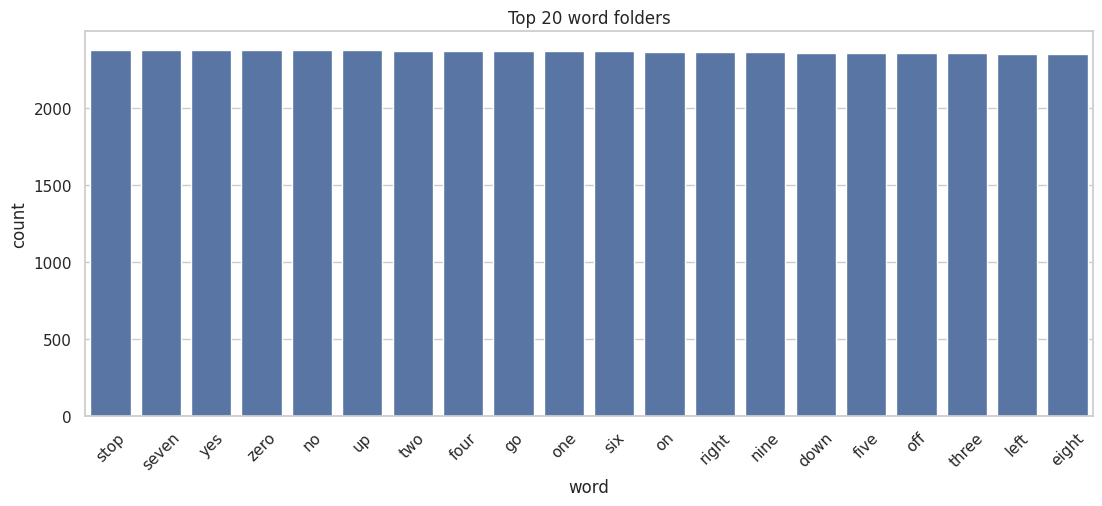

In [34]:
word_counts = all_files['word'].value_counts().reset_index()
word_counts.columns = ['word', 'count']

display(word_counts.head(20))

plt.figure(figsize=(13, 5))
sns.barplot(data=word_counts.head(20), x='word', y='count')
plt.xticks(rotation=45)
plt.title('Top 20 word folders')
plt.show()

,count
label,
yes,2377
no,2375
up,2375
down,2359
left,2353
right,2367
on,2367
off,2357
stop,2380


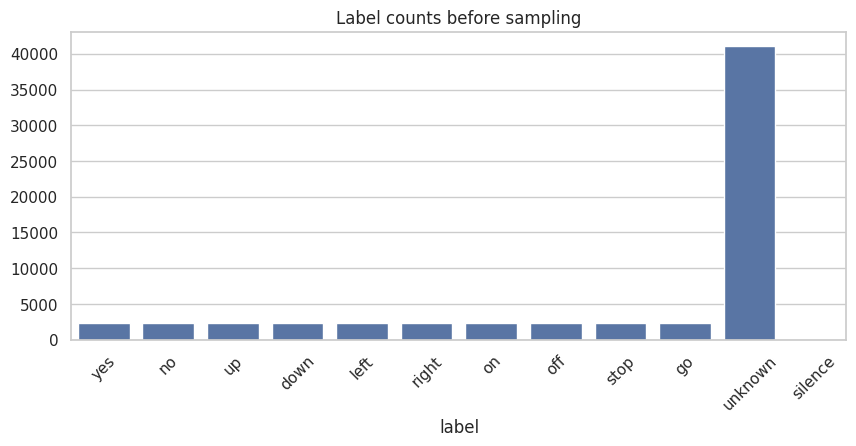

In [35]:
label_counts = all_files['label'].value_counts().reindex(LABELS).fillna(0).astype(int)

display(label_counts.to_frame('count'))

plt.figure(figsize=(10, 4))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xticks(rotation=45)
plt.title('Label counts before sampling')
plt.show()

,relpath,label,duration
50866,three/a8f45bdc_nohash_0.wav,unknown,1.0
1003,bed/9b027ecf_nohash_1.wav,unknown,1.0
38126,one/fb9d6d23_nohash_0.wav,unknown,1.0
144,bed/18c54a68_nohash_2.wav,unknown,1.0
31651,off/413997c1_nohash_1.wav,off,1.0


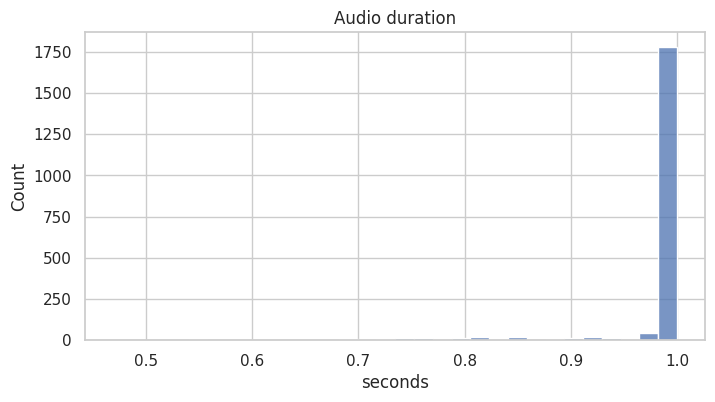

In [36]:
duration_sample = all_files.sample(min(2000, len(all_files)), random_state=SEED).copy()

durations = []

for path in duration_sample['path']:
    info = sf.info(path)
    durations.append(info.frames / info.samplerate)

duration_sample['duration'] = durations

display(duration_sample[['relpath', 'label', 'duration']].head())

plt.figure(figsize=(8, 4))
sns.histplot(duration_sample['duration'], bins=30)
plt.xlabel('seconds')
plt.title('Audio duration')
plt.show()

file: yes/004ae714_nohash_0.wav
sample rate: 16000
shape: (16000,)


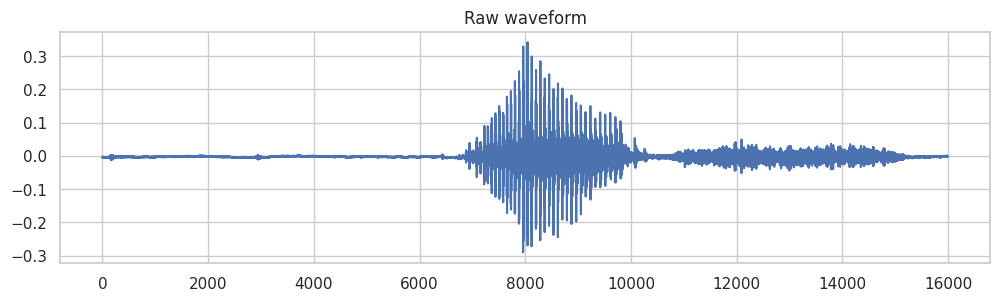

In [37]:
one_row = all_files[all_files['label'] == 'yes'].iloc[0]

audio, sr = sf.read(one_row['path'], dtype='float32')

if audio.ndim == 2:
    audio = audio.mean(axis=1)

print('file:', one_row['relpath'])
print('sample rate:', sr)
print('shape:', audio.shape)

plt.figure(figsize=(12, 3))
plt.plot(audio)
plt.title('Raw waveform')
plt.show()

## Train / validation split


In [38]:
validation_path = TRAIN_AUDIO_DIR.parent / 'validation_list.txt'
testing_path = TRAIN_AUDIO_DIR.parent / 'testing_list.txt'

validation_set = set(validation_path.read_text().splitlines())
testing_set = set(testing_path.read_text().splitlines())

all_files['split'] = 'train'
all_files.loc[all_files['relpath'].isin(validation_set), 'split'] = 'valid'
all_files.loc[all_files['relpath'].isin(testing_set), 'split'] = 'ignore'

usable_files = all_files[all_files['split'] != 'ignore'].copy()

display(pd.crosstab(usable_files['label'], usable_files['split']).reindex(LABELS))

split,train,valid
label,,
yes,1860.0,261.0
no,1853.0,270.0
up,1843.0,260.0
down,1842.0,264.0
left,1839.0,247.0
right,1852.0,256.0
on,1864.0,257.0
off,1839.0,256.0
stop,1885.0,246.0


## unknown 언더샘플링



In [39]:
train_known = usable_files[(usable_files['split'] == 'train') & (usable_files['label'].isin(TARGET_WORDS))].copy()
valid_known = usable_files[(usable_files['split'] == 'valid') & (usable_files['label'].isin(TARGET_WORDS))].copy()

train_unknown_pool = usable_files[(usable_files['split'] == 'train') & (usable_files['label'] == 'unknown')].copy()
valid_unknown_pool = usable_files[(usable_files['split'] == 'valid') & (usable_files['label'] == 'unknown')].copy()

normal_train_count = int(train_known['label'].value_counts().mean())
normal_valid_count = int(valid_known['label'].value_counts().mean())

train_unknown = train_unknown_pool.sample(min(len(train_unknown_pool), normal_train_count), random_state=SEED)
valid_unknown = valid_unknown_pool.sample(min(len(valid_unknown_pool), normal_valid_count), random_state=SEED)

train_table = pd.concat([train_known, train_unknown], ignore_index=True)
valid_table = pd.concat([valid_known, valid_unknown], ignore_index=True)

print('train before silence:', len(train_table))
print('valid before silence :', len(valid_table))

display(train_table['label'].value_counts().reindex(LABELS))

train before silence: 20391
valid before silence : 2834


label
yes        1860.0
no         1853.0
up         1843.0
down       1842.0
left       1839.0
right      1852.0
on         1864.0
off        1839.0
stop       1885.0
go         1861.0
unknown    1853.0
silence       NaN
Name: count, dtype: float64

##  silence 추가


In [40]:
noise_dir = TRAIN_AUDIO_DIR / '_background_noise_'
noise_files = sorted(noise_dir.glob('*.wav'))

silence_rows_train = []
silence_rows_valid = []

silence_train_count = int(normal_train_count * 0.2)
silence_valid_count = int(normal_valid_count * 0.2)

rng = np.random.default_rng(SEED)

for i in range(silence_train_count):
    noise_path = noise_files[int(rng.integers(0, len(noise_files)))]
    info = sf.info(str(noise_path))
    max_start = max(0, info.frames - AUDIO_LENGTH)
    start = int(rng.integers(0, max_start + 1))

    silence_rows_train.append(
        {
            'path': str(noise_path),
            'relpath': f'silence/train_{i}.wav',
            'word': 'silence',
            'label': 'silence',
            'start': start,
            'augment': False,
            'split': 'train',
        }
    )

for i in range(silence_valid_count):
    noise_path = noise_files[int(rng.integers(0, len(noise_files)))]
    info = sf.info(str(noise_path))
    max_start = max(0, info.frames - AUDIO_LENGTH)
    start = int(rng.integers(0, max_start + 1))

    silence_rows_valid.append(
        {
            'path': str(noise_path),
            'relpath': f'silence/valid_{i}.wav',
            'word': 'silence',
            'label': 'silence',
            'start': start,
            'augment': False,
            'split': 'valid',
        }
    )

train_table = pd.concat([train_table, pd.DataFrame(silence_rows_train)], ignore_index=True)
valid_table = pd.concat([valid_table, pd.DataFrame(silence_rows_valid)], ignore_index=True)

train_table = train_table.sample(frac=1, random_state=SEED).reset_index(drop=True)
valid_table = valid_table.sample(frac=1, random_state=SEED).reset_index(drop=True)

display(pd.concat([
    train_table['label'].value_counts().rename('train'),
    valid_table['label'].value_counts().rename('valid'),
], axis=1).reindex(LABELS))

,train,valid
label,,
yes,1860,261
no,1853,270
up,1843,260
down,1842,264
left,1839,247
right,1852,256
on,1864,257
off,1839,256
stop,1885,246


## oversampling



In [41]:
train_counts = train_table['label'].value_counts()
target_count = int(train_counts.median())

extra_tables = []

for label in LABELS:
    label_rows = train_table[train_table['label'] == label]
    need = target_count - len(label_rows)

    if need > 0:
        extra_rows = label_rows.sample(need, replace=True, random_state=SEED).copy()
        extra_rows['augment'] = True
        extra_tables.append(extra_rows)

if extra_tables:
    train_table = pd.concat([train_table] + extra_tables, ignore_index=True)

train_table = train_table.sample(frac=1, random_state=SEED).reset_index(drop=True)

if not FULL_RUN:
    train_table = train_table.sample(min(1200, len(train_table)), random_state=SEED).reset_index(drop=True)
    valid_table = valid_table.sample(min(300, len(valid_table)), random_state=SEED).reset_index(drop=True)

print('final train:', len(train_table))
print('final valid :', len(valid_table))

display(train_table['label'].value_counts().reindex(LABELS))
display(train_table['augment'].value_counts())

final train: 22288
final valid : 2885


label
yes        1860
no         1853
up         1852
down       1852
left       1852
right      1852
on         1864
off        1852
stop       1885
go         1861
unknown    1853
silence    1852
Name: count, dtype: int64

augment
False    20761
True      1527
Name: count, dtype: int64

## 오디오를 읽어서 1초로 맞추는 함수


In [42]:
def read_audio_1sec(path, start=0):
    audio, sr = sf.read(path, start=int(start), frames=AUDIO_LENGTH, dtype='float32')

    if audio.ndim == 2:
        audio = audio.mean(axis=1)

    if sr != SAMPLE_RATE:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=SAMPLE_RATE)

    if len(audio) < AUDIO_LENGTH:
        audio = np.pad(audio, (0, AUDIO_LENGTH - len(audio)))

    audio = audio[:AUDIO_LENGTH]

    return audio.astype(np.float32)


sample_audio = read_audio_1sec(train_table.iloc[0]['path'], train_table.iloc[0]['start'])

print(sample_audio.shape)
print(sample_audio.dtype)

(16000,)
float32


## Augmentation



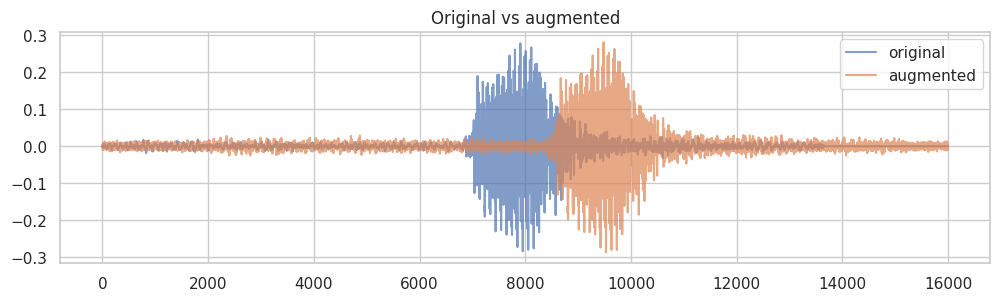

In [43]:
original = read_audio_1sec(train_table.iloc[0]['path'], train_table.iloc[0]['start'])

shift = np.random.randint(-1600, 1601)
augmented = np.roll(original, shift)

noise = np.random.normal(0, 0.005, size=len(augmented))
augmented = augmented + noise
augmented = augmented.astype(np.float32)

plt.figure(figsize=(12, 3))
plt.plot(original, label='original', alpha=0.7)
plt.plot(augmented, label='augmented', alpha=0.7)
plt.legend()
plt.title('Original vs augmented')
plt.show()

In [44]:
train_hf = Dataset.from_pandas(train_table, preserve_index=False)
valid_hf = Dataset.from_pandas(valid_table, preserve_index=False)

datasets = DatasetDict(
    {
        'train': train_hf,
        'valid': valid_hf,
    }
)

print(datasets)
print(datasets['train'][0])

DatasetDict({
    train: Dataset({
        features: ['path', 'relpath', 'word', 'label', 'start', 'augment', 'split'],
        num_rows: 22288
    })
    valid: Dataset({
        features: ['path', 'relpath', 'word', 'label', 'start', 'augment', 'split'],
        num_rows: 2885
    })
})
{'path': '/content/data/raw/train/audio/up/e4a2cf79_nohash_3.wav', 'relpath': 'up/e4a2cf79_nohash_3.wav', 'word': 'up', 'label': 'up', 'start': 0, 'augment': False, 'split': 'train'}


In [45]:
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_NAME)


def preprocess_batch(batch):
    audio_list = []

    for path, start, do_augment in zip(batch['path'], batch['start'], batch['augment']):
        audio = read_audio_1sec(path, start)

        if do_augment:
            shift = np.random.randint(-1600, 1601)
            audio = np.roll(audio, shift)
            audio = audio + np.random.normal(0, 0.005, size=len(audio))
            audio = audio.astype(np.float32)

        audio_list.append(audio)

    inputs = feature_extractor(
        audio_list,
        sampling_rate=SAMPLE_RATE,
        max_length=AUDIO_LENGTH,
        truncation=True,
        padding='max_length',
    )

    inputs['labels'] = [label2id[label] for label in batch['label']]

    return inputs


encoded_datasets = datasets.map(
    preprocess_batch,
    batched=True,
    batch_size=32,
    remove_columns=datasets['train'].column_names,
)

print(encoded_datasets)
print(encoded_datasets['train'][0].keys())

Map:   0%|          | 0/22288 [00:00<?, ? examples/s]

Map:   0%|          | 0/2885 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_values', 'labels'],
        num_rows: 22288
    })
    valid: Dataset({
        features: ['input_values', 'labels'],
        num_rows: 2885
    })
})
dict_keys(['input_values', 'labels'])


## Model

In [46]:
model = AutoModelForAudioClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,
)

model.freeze_feature_encoder()

print('model loaded')

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_q.bias               | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
projector.bias               | MISSING    | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 
projector.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model loaded


In [47]:
def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    true_ids = eval_pred.label_ids
    pred_ids = np.argmax(logits, axis=1)

    return {
        'accuracy': accuracy_score(true_ids, pred_ids),
        'macro_f1': f1_score(true_ids, pred_ids, average='macro'),
    }

## 학습

In [52]:
EPOCHS = 5 if FULL_RUN else 1
TRAIN_BATCH_SIZE = 16 if FULL_RUN else 4
EVAL_BATCH_SIZE = 32 if FULL_RUN else 8

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / 'wav2vec2_simple'),
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=3e-5,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=2,
    num_train_epochs=EPOCHS,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_datasets['train'],
    eval_dataset=encoded_datasets['valid'],
    processing_class=feature_extractor,
    compute_metrics=compute_metrics,
)

trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.412901,0.176647,0.961525,0.958599
2,0.429006,0.155441,0.964298,0.966910
3,0.434437,0.156512,0.965685,0.967659
4,0.337221,0.123990,0.970191,0.970476
5,0.364125,0.123823,0.970191,0.970451


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3485, training_loss=0.3947432292243159, metrics={'train_runtime': 1553.5343, 'train_samples_per_second': 71.733, 'train_steps_per_second': 2.243, 'total_flos': 1.0117503158784e+18, 'train_loss': 0.3947432292243159, 'epoch': 5.0})

## Validation 결과 확인


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.364125,0.123990,5,0.970191,0.970476


{'eval_loss': 0.12398969382047653, 'eval_accuracy': 0.9701906412478336, 'eval_macro_f1': 0.9704755228446708}


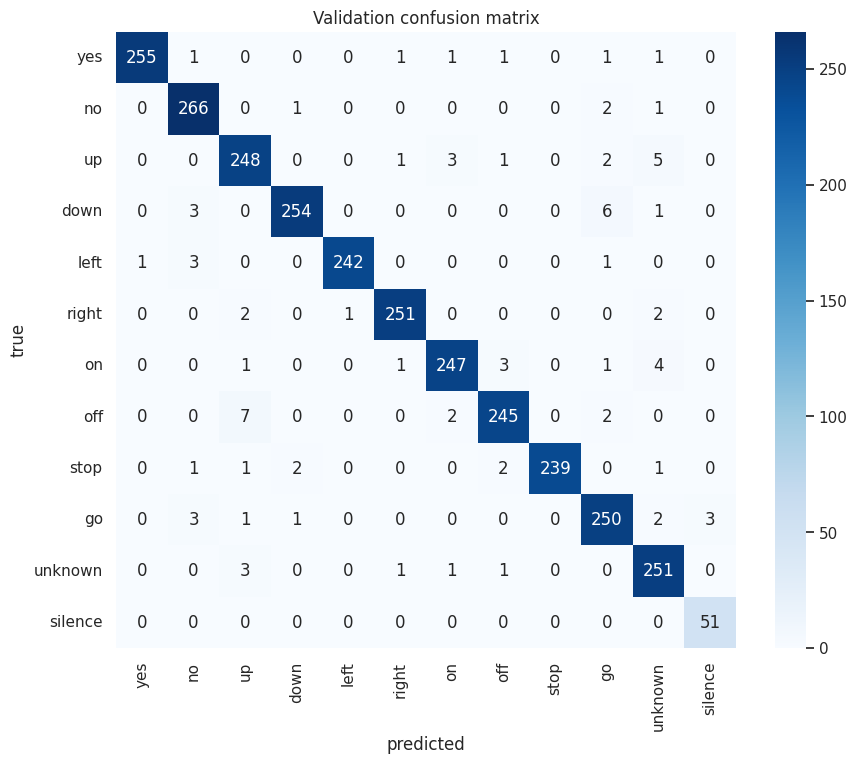

accuracy: 0.9701906412478336
macro_f1: 0.9704755228446708


In [56]:
metrics = trainer.evaluate()
print(metrics)

pred_output = trainer.predict(encoded_datasets['valid'])

valid_true = pred_output.label_ids
valid_pred = np.argmax(pred_output.predictions, axis=1)

matrix = confusion_matrix(valid_true, valid_pred, labels=list(range(len(LABELS))))

plt.figure(figsize=(10, 8))
sns.heatmap(
    matrix,
    annot=True,
    fmt='d',
    xticklabels=LABELS,
    yticklabels=LABELS,
    cmap='Blues',
)
plt.xlabel('predicted')
plt.ylabel('true')
plt.title('Validation confusion matrix')
plt.show()

print('accuracy:', accuracy_score(valid_true, valid_pred))
print('macro_f1:', f1_score(valid_true, valid_pred, average='macro'))

In [54]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model.to(device)
model.eval()

test_files = sorted(TEST_AUDIO_DIR.glob('*.wav'))
print('test files:', len(test_files))

batch_size = 64
submission_rows = []

for start_index in range(0, len(test_files), batch_size):
    batch_files = test_files[start_index : start_index + batch_size]
    batch_audio = []

    for path in batch_files:
        audio = read_audio_1sec(str(path), start=0)
        batch_audio.append(audio)

    inputs = feature_extractor(
        batch_audio,
        sampling_rate=SAMPLE_RATE,
        max_length=AUDIO_LENGTH,
        truncation=True,
        padding='max_length',
        return_tensors='pt',
    )

    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits

    pred_ids = torch.argmax(logits, dim=1).cpu().numpy()

    for path, pred_id in zip(batch_files, pred_ids):
        submission_rows.append({'fname': path.name, 'label': id2label[int(pred_id)]})

    if start_index % 6400 == 0:
        print(start_index, '/', len(test_files))

submission = pd.DataFrame(submission_rows)

display(submission.head())
display(submission['label'].value_counts())

test files: 158538
0 / 158538
6400 / 158538
12800 / 158538
19200 / 158538
25600 / 158538
32000 / 158538
38400 / 158538
44800 / 158538
51200 / 158538
57600 / 158538
64000 / 158538
70400 / 158538
76800 / 158538
83200 / 158538
89600 / 158538
96000 / 158538
102400 / 158538
108800 / 158538
115200 / 158538
121600 / 158538
128000 / 158538
134400 / 158538
140800 / 158538
147200 / 158538
153600 / 158538


,fname,label
0,clip_000044442.wav,no
1,clip_0000adecb.wav,unknown
2,clip_0000d4322.wav,unknown
3,clip_0000fb6fe.wav,up
4,clip_0001d1559.wav,unknown


label
unknown    84722
off         8201
silence     8127
go          7236
no          7161
on          6900
right       6614
up          6593
left        6246
stop        5876
yes         5480
down        5382
Name: count, dtype: int64

## 제출 파일 저장

In [55]:
submission_path = OUTPUT_DIR / 'submission.csv'
submission.to_csv(submission_path, index=False)

print('saved:', submission_path)

from google.colab import files
files.download(str(submission_path))

saved: /content/outputs/submission.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>